C:\Users\ASUS\PycharmProjects\JupyterProject3\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8529 - loss: 0.4167 - val_accuracy: 0.8880 - val_loss: 0.3143
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8997 - loss: 0.2839 - val_accuracy: 0.9022 - val_loss: 0.2792
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9132 - loss: 0.2406 - val_accuracy: 0.8845 - val_loss: 0.3086
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9242 - loss: 0.2100 - val_accuracy: 0.9080 - val_loss: 0.2623
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9324 - loss: 0.1844 - val_accuracy: 0.9085 - val_loss: 0.2586
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9410 - loss: 0.1618 - val_accuracy: 0.9052 - val_loss: 0.2782
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9488 - loss: 0.1430 - val_accuracy: 0.9115 - val_loss: 0.2662
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9549 - loss: 0.1246 -

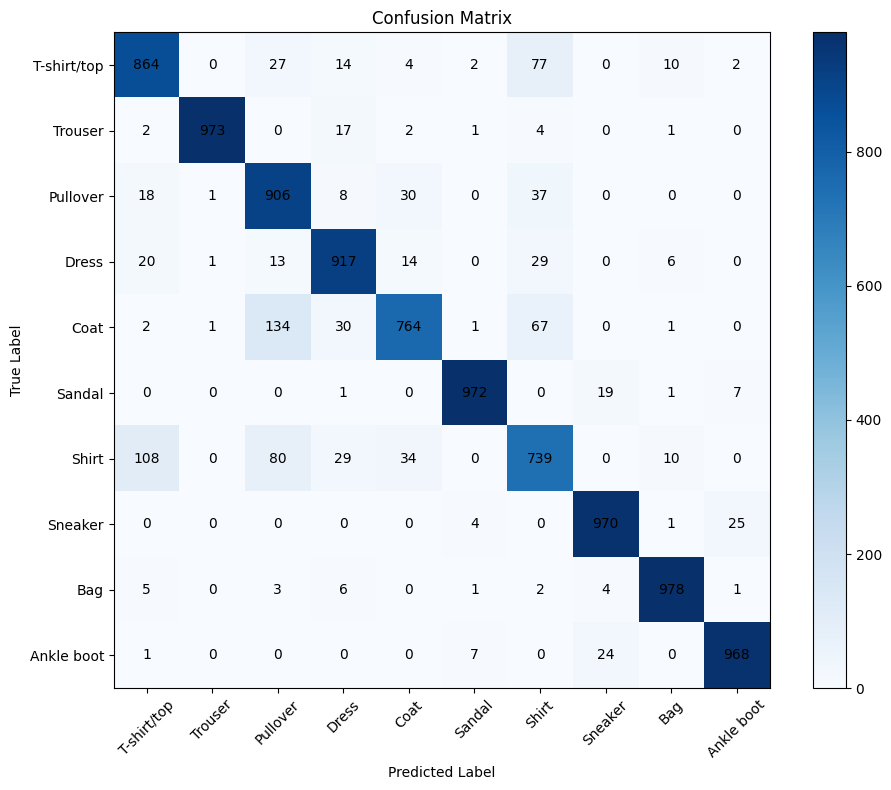

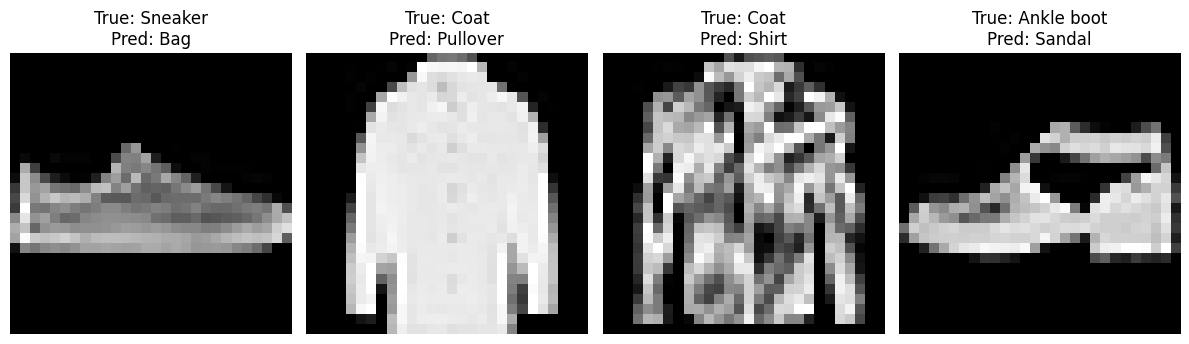

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 2) Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# 3) Reshape images to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 4) Build the CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 5) Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6) Train the model
cnn_model.fit(X_train, y_train, epochs=15, validation_split=0.1)

# Generate predictions on the test set
# model, x_test, and y_test are assumed to come from Question 6
predictions = cnn_model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

# Compute the confusion matrix
conf_matrix = tf.math.confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(10), labels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add the numbers inside each cell
for i in range(10):
    for j in range(10):
        plt.text(j, i, int(conf_matrix[i, j]),
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Find misclassified images
misclassified_indices = np.where(y_pred != y_test)[0]

# Visualize at least three misclassified images
plt.figure(figsize=(12, 4))

for i in range(4):
    idx = misclassified_indices[i]
    plt.subplot(1, 4, i + 1)

    # x_test images were reshaped to (28, 28, 1), so squeeze removes the channel dimension
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Pattern observed in misclassifications:
# A common pattern is that the CNN often confuses visually similar clothing items,
# such as T-shirt/top, Shirt, Pullover, and Coat, because their shapes and textures
# can look alike in small 28x28 grayscale images.

# One realistic way to improve CNN performance:
# We could improve the model by using a deeper CNN with more convolution layers,
# adding dropout for regularization, and/or using data augmentation so the model
# learns more robust image features.
